In [2]:
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

regions = gpd.read_file("data\\Localities_LGATE_234_WA_GDA2020_Public_Geopackage\\Localities_LGATE_234_WA_GDA2020_Public.gpkg")

# print(regions.info())

In [4]:
metro = regions[
    regions["postcode"].astype(int).between(6000,6199)
]


#print(metro_mines.head())
print(metro.info())
print(metro.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 375 entries, 9 to 1715
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   boundary_id          375 non-null    int32   
 1   type_code            375 non-null    int16   
 2   type_description     375 non-null    object  
 3   feature_number       375 non-null    int32   
 4   name                 375 non-null    object  
 5   abs_lga_number       0 non-null      float64 
 6   postcode             375 non-null    object  
 7   land_area            375 non-null    float64 
 8   area_derivation      375 non-null    object  
 9   st_area_shape_       375 non-null    float64 
 10  st_perimeter_shape_  375 non-null    float64 
 11  geometry             375 non-null    geometry
dtypes: float64(4), geometry(1), int16(1), int32(2), object(4)
memory usage: 33.0+ KB
None
    boundary_id  type_code type_description  feature_number            name  \
9      

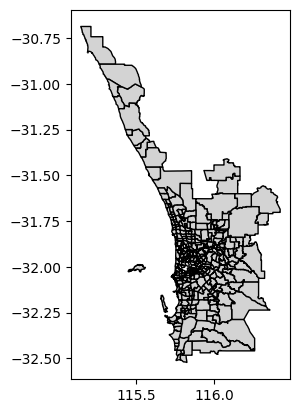

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

metro.plot(ax=ax,
           facecolor="lightgray",
           edgecolor="black")


plt.show()

In [ ]:
def gdf_to_graph(gdf: gpd.GeoDataFrame, idx:str) -> nx.Graph:
    """
    Convert a GeoDataFrame into an undirected NetworkX graph.

    Notes
    -----
    - Only Polygon and MultiPolygon geometries are converted.
    - Every row becomes one node.
    - Every GeoDataFrame column is stored as a node attribute.
    - Two polygons are connected if they are spatially adjacent

    Parameters
    ----------
    gdf : GeoDataFrame
    idx : The column name of GeoPanda that to be used as node name

    Returns
    -------
    nx.Graph
    """
    # Defensive Input Check
    if not isinstance(gdf, gpd.GeoDataFrame):
        raise TypeError("Input must be a GeoDataFrame.")

    if idx not in gdf.columns:
        raise ValueError(f"Column '{idx}' does not exist in GeoDataFrame.")

    # Keep polygons only
    gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

    # calculate the centroids
    gdf['centroid'] = gdf.centroid

    G = nx.Graph()

    # -------------------------
    # Add nodes
    # -------------------------
    for row_id, row in gdf.iterrows():

        node_name = row[idx]

        attrs = row.to_dict()

        # optional: remove geometry attribute
        attrs.pop("geometry")
        attrs.pop(idx)

        # save centroid coordinate
        attrs["x"] = row.centroid.x
        attrs["y"] = row.centroid.y

        G.add_node(node_name, **attrs)


    # -------------------------
    # Spatial adjacency
    # -------------------------
    sindex = gdf.sindex

    for row_id, geom in enumerate(gdf.geometry):

        node_a = gdf.iloc[row_id][idx]

        candidates = list(
            sindex.intersection(geom.bounds)
        )

        for other_id in candidates:

            if other_id <= row_id:
                continue

            other_geom = gdf.iloc[other_id].geometry

            if geom.touches(other_geom):

                node_b = gdf.iloc[other_id][idx]

                G.add_edge(node_a, node_b)

    return G


C:\Users\YLM\AppData\Local\Temp\ipykernel_2304\403193118.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.centroid


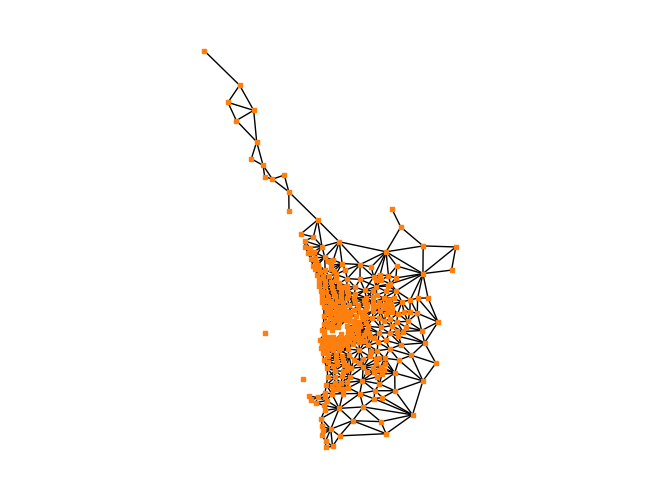

In [7]:


metro_graph = gdf_to_graph(gdf=metro, idx='name')

pos = {
    node: (
        data["x"],
        data["y"]
    )
    for node, data in metro_graph.nodes(data=True)
}

nx.draw(G=metro_graph,
        pos=pos,
        node_color='C1',
        node_shape='s',
        node_size=5,
        with_labels=False,
        font_size=3)

plt.axis("equal")
plt.show()